In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor

## Đọc dữ liệu

In [2]:
df = pd.read_csv(r"D:\UNIVERSITY\ĐACN\BI-Dashboard-Project\data\live\sales_dashboard.csv")
df.head()

,order_id,order_purchase_timestamp,price,freight_value,payment_value,order_status,seller_id,customer_unique_id,customer_city,customer_state,product_category_name,Category_VN,product_id
0,e481f51cbdc54678b7cc49136f2d6af7,2017-10-02 10:56:33,29.99,8.72,38.71,delivered,3504c0cb71d7fa48d967e0e4c94d59d9,7c396fd4830fd04220f754e42b4e5bff,sao paulo,SP,utilidades_domesticas,Đồ gia dụng,87285b34884572647811a353c7ac498a
1,949d5b44dbf5de918fe9c16f97b45f8a,2017-11-18 19:28:06,45.00,27.20,72.20,delivered,66922902710d126a0e7d26b0e3805106,7c142cf63193a1473d2e66489a9ae977,sao goncalo do amarante,RN,pet_shop,Thú cưng,d0b61bfb1de832b15ba9d266ca96e5b0
2,ad21c59c0840e6cb83a9ceb5573f8159,2018-02-13 21:18:39,19.90,8.72,28.62,delivered,2c9e548be18521d1c43cde1c582c6de8,72632f0f9dd73dfee390c9b22eb56dd6,santo andre,SP,papelaria,Văn phòng phẩm,65266b2da20d04dbe00c5c2d3bb7859e
3,a4591c265e18cb1dcee52889e2d8acc3,2017-07-09 21:57:05,147.90,27.36,175.26,delivered,8581055ce74af1daba164fdbd55a40de,80bb27c7c16e8f973207a5086ab329e2,congonhinhas,PR,automotivo,Phụ tùng ô tô,060cb19345d90064d1015407193c233d
4,6514b8ad8028c9f2cc2374ded245783f,2017-05-16 13:10:30,59.99,15.17,75.16,delivered,16090f2ca825584b5a147ab24aa30c86,932afa1e708222e5821dac9cd5db4cae,nilopolis,RJ,automotivo,Phụ tùng ô tô,4520766ec412348b8d4caa5e8a18c464


## Kiểm tra dữ liệu

In [3]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101469 entries, 0 to 101468
Data columns (total 13 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   order_id                  101469 non-null  object 
 1   order_purchase_timestamp  101469 non-null  object 
 2   price                     101469 non-null  float64
 3   freight_value             101469 non-null  float64
 4   payment_value             101469 non-null  float64
 5   order_status              101469 non-null  object 
 6   seller_id                 101469 non-null  object 
 7   customer_unique_id        101469 non-null  object 
 8   customer_city             101469 non-null  object 
 9   customer_state            101469 non-null  object 
 10  product_category_name     101469 non-null  object 
 11  Category_VN               101469 non-null  object 
 12  product_id                101469 non-null  object 
dtypes: float64(3), object(10)
memory usage: 10.1

,price,freight_value,payment_value
count,101469.000000,101469.000000,101469.000000
mean,120.068787,19.869711,179.993615
std,181.656081,15.480839,274.387174
min,0.850000,0.000000,10.070000
25%,39.900000,13.080000,65.710000
50%,74.990000,16.200000,114.490000
75%,134.900000,21.060000,195.360000
max,6735.000000,409.680000,13664.080000


## Kiểm tra và xử lý dữ liệu thiếu

In [4]:
df.isnull().sum()
df = df.dropna()

In [5]:
## XỬ LÝ THỜI GIAN

In [6]:
df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'])

In [7]:
## 👉 GỘP THEO NGÀY

In [8]:
df['date'] = df['order_purchase_timestamp'].dt.date

df_daily = df.groupby('date')['payment_value'].sum().reset_index()
df_daily.columns = ['date','revenue']

df_daily['date'] = pd.to_datetime(df_daily['date'])
df_daily = df_daily.sort_values('date')


In [9]:
##  FEATURE ENGINEERING

In [10]:
df_daily['dayofweek'] = df_daily['date'].dt.dayofweek
df_daily['month'] = df_daily['date'].dt.month

df_daily['lag1'] = df_daily['revenue'].shift(1)
df_daily['lag7'] = df_daily['revenue'].shift(7)
df_daily['lag14'] = df_daily['revenue'].shift(14)

df_daily['rolling7'] = df_daily['revenue'].rolling(7).mean()
df_daily['rolling14'] = df_daily['revenue'].rolling(14).mean()

df_daily = df_daily.dropna()


In [11]:
## TRAIN TEST SPLIT (TIME SERIES)

In [12]:
test_days = 30

train = df_daily.iloc[:-test_days]
test = df_daily.iloc[-test_days:]

X_train = train.drop(columns=['revenue','date'])
y_train = train['revenue']

X_test = test.drop(columns=['revenue','date'])
y_test = test['revenue']

In [13]:
##  TRAIN MODEL XGBOOST

In [14]:
# XGBoost
xgb = XGBRegressor(
    n_estimators=500,
    learning_rate=0.03,
    max_depth=5,
    random_state=42
)
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)

In [15]:
## EVALUATION

In [16]:

def evaluate(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    return round(mae,2), round(rmse,2)


mae_xgb, rmse_xgb = evaluate(y_test, y_pred_xgb)

print("📊 EVALUATION:")

print("XGBoost - MAE:", mae_xgb, "| RMSE:", rmse_xgb)

📊 EVALUATION:
XGBoost - MAE: 8509.25 | RMSE: 10910.47


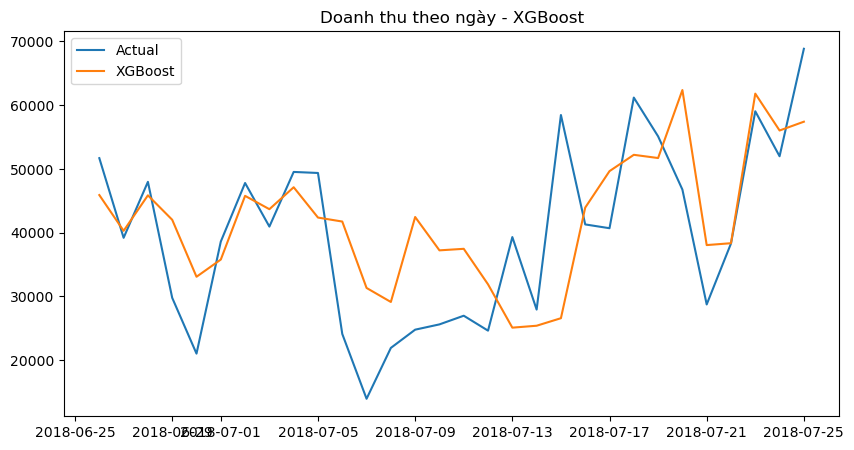

In [17]:
plt.figure(figsize=(10,5))
plt.plot(test['date'], y_test, label='Actual')
plt.plot(test['date'], y_pred_xgb, label='XGBoost') 
plt.legend()
plt.title("Doanh thu theo ngày - XGBoost")
plt.show()

In [18]:
##  TRAIN LẠI FULL DATA

In [19]:
X_full = df_daily.drop(columns=['revenue','date'])
y_full = df_daily['revenue']


xgb_final = XGBRegressor(
    n_estimators=500,
    learning_rate=0.03,
    max_depth=5,
    random_state=42
)
xgb_final.fit(X_full, y_full)

XGBRegressor(base_score=0.5, booster='gbtree', callbacks=None,
             colsample_bylevel=1, colsample_bynode=1, colsample_bytree=1,
             early_stopping_rounds=None, enable_categorical=False,
             eval_metric=None, gamma=0, gpu_id=-1, grow_policy='depthwise',
             importance_type=None, interaction_constraints='',
             learning_rate=0.03, max_bin=256, max_cat_to_onehot=4,
             max_delta_step=0, max_depth=5, max_leaves=0, min_child_weight=1,
             missing=nan, monotone_constraints='()', n_estimators=500, n_jobs=0,
             num_parallel_tree=1, predictor='auto', random_state=42,
             reg_alpha=0, reg_lambda=1, ...)

In [20]:
## FORECAST FUTURE (QUAN TRỌNG)

In [21]:
future_days = 30
future_preds_xgb = []

df_future = df_daily.copy()

# 👉 PHẢI GIỐNG LÚC TRAIN
FEATURES = [
    'dayofweek','month',
    'lag1','lag7','lag14',
    'rolling7','rolling14'
]

for i in range(future_days):
    
    last_row = df_future.iloc[-1:].copy()
    
    # ===== NGÀY TIẾP THEO =====
    next_date = last_row['date'].values[0] + np.timedelta64(1, 'D')
    
    new_row = pd.DataFrame({'date':[next_date]})
    
    # ===== TIME FEATURE =====
    new_row['dayofweek'] = pd.to_datetime(new_row['date']).dt.dayofweek
    new_row['month'] = pd.to_datetime(new_row['date']).dt.month
    
    # ===== LAG =====
    new_row['lag1'] = df_future['revenue'].iloc[-1]
    new_row['lag7'] = df_future['revenue'].iloc[-7]
    new_row['lag14'] = df_future['revenue'].iloc[-14]
    
    # ===== ROLLING =====
    new_row['rolling7'] = df_future['revenue'].iloc[-7:].mean()
    new_row['rolling14'] = df_future['revenue'].iloc[-14:].mean()
    
    # ===== FIX CỨNG FEATURE (QUAN TRỌNG NHẤT) =====
    X_new = new_row[FEATURES]
    
    # ===== PREDICT =====
    pred_xgb = xgb_final.predict(X_new)[0]
    
    # ===== GÁN KẾT QUẢ =====
    new_row['revenue'] = pred_xgb
    
    df_future = pd.concat([df_future, new_row], ignore_index=True)
  
    future_preds_xgb.append(pred_xgb)

In [22]:
## VISUALIZE FUTURE

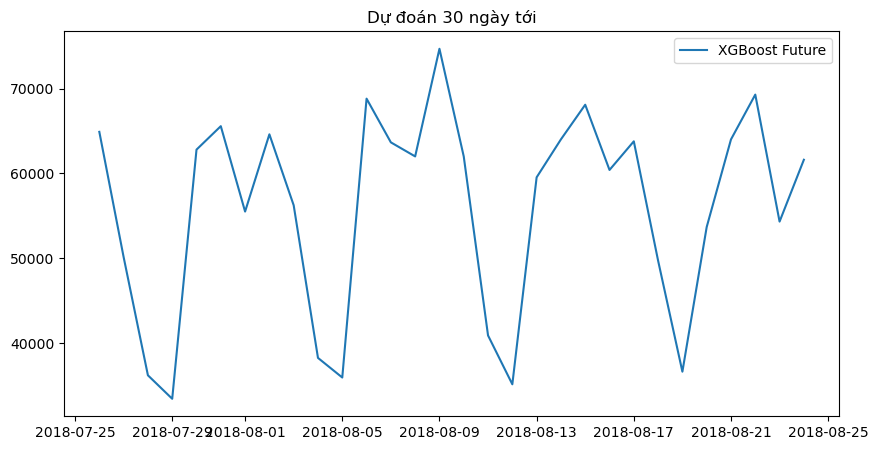

In [23]:
future_dates = df_future['date'].iloc[-future_days:]

plt.figure(figsize=(10,5))
plt.plot(future_dates, future_preds_xgb, label='XGBoost Future')
plt.legend()
plt.title("Dự đoán 30 ngày tới")
plt.show()

### Lưu model vào file bkl

In [24]:
import pickle


with open(r"D:\UNIVERSITY\ĐACN\BI-Dashboard-Project\models\xgboost_model.pkl", "wb") as f:
    pickle.dump(xgb_final, f)

In [25]:
xgb = pickle.load(open(r"D:\UNIVERSITY\ĐACN\BI-Dashboard-Project\models\xgboost_model.pkl","rb"))

In [26]:
print(xgb.get_booster().feature_names)

['dayofweek', 'month', 'lag1', 'lag7', 'lag14', 'rolling7', 'rolling14']
